# Tarea 4
Integrantes:
- Pablo Lores
- Ignacio Marambio
#### PARTE 1. (50%)
1. Utilice una imagen descargada de internet. De dicha imagen sólo utilice una sección de 256x256 píxeles. Genere distintas versiones de la imagen original empleando distintos modelos de ruido. Los ruidos que debe emplear corresponden a: <br/>
    (1) ruido gaussiano <br/>
    (2) uniforme <br/>
    (3) impulsional-sal <br/>
    (4) impulsional-pimienta <br/>
Usted debe definir el nivel de ruido para cada imagen. Se deja a elección definir el nivel de ruido en cada modelo. En total usted debe generar cuatro imágenes con los ruidos indicados previamente. <br/>

2. Para cada imagen ruidosa determine el filtro que mejor reduzca ruido. Utilice sólo un filtro por cada imagen. No obstante, el filtro que usted seleccione debe pertenecer a una de las tres familias de filtros en el espacio. Esto significa que al menos debe haber un filtro de orden estadístico, un filtro adaptivo, y un filtro lineal implementado en su tarea. Explique las razones por las cuales el filtro que usted seleccionó es mejor que otros filtros.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

# Parte 1: Análisis y Filtrado de Ruido en Imágenes

## Análisis de los Filtros Aplicados

En esta sección, analizamos los resultados obtenidos después de aplicar diferentes tipos de filtros a imágenes con distintos tipos de ruido. A continuación se presenta una evaluación detallada de cada tipo de ruido y el filtro seleccionado:

### 1. Ruido Gaussiano → Filtro Gaussiano (Lineal)

El ruido gaussiano se caracteriza por una distribución normal que afecta todos los píxeles de manera independiente. Para este tipo de ruido, el filtro gaussiano demostró ser el más efectivo debido a que:

- Su kernel está diseñado específicamente para suavizar el ruido con distribución normal
- Preserva mejor los bordes y detalles que el filtro de promedio simple
- La ponderación gaussiana respeta mejor las estructuras de la imagen original

### 2. Ruido Uniforme → Filtro Wiener Local (Adaptativo)

Para el ruido uniforme, donde cada píxel se ve afectado por una variable aleatoria con distribución uniforme, el filtro Wiener local resultó ser la mejor opción porque:

- Se adapta a las características locales de cada región de la imagen
- Preserva detalles en áreas de alta varianza (bordes, texturas)
- Reduce el ruido de manera más efectiva en regiones homogéneas
- Mantiene un mejor equilibrio entre suavizado y preservación de detalles

### 3. Ruido Sal → Filtro Mínimo (Orden Estadístico)

El ruido "sal" genera píxeles blancos aleatorios en la imagen. El filtro de mínimo demostró ser particularmente efectivo porque:

- Elimina selectivamente los píxeles de alta intensidad (blancos)
- Preserva la estructura original de las áreas oscuras
- Actúa como una operación morfológica específicamente adaptada a este tipo de ruido

### 4. Ruido Pimienta → Filtro Mediana (Orden Estadístico)

Para el ruido "pimienta" (píxeles negros aleatorios), el filtro de mediana proporcionó los mejores resultados porque:

- Es altamente efectivo para eliminar valores atípicos extremos
- Preserva bordes mejor que los filtros lineales
- No introduce nuevos valores de intensidad como lo hacen los filtros lineales
- Funciona bien incluso con niveles moderados o altos de ruido impulsivo

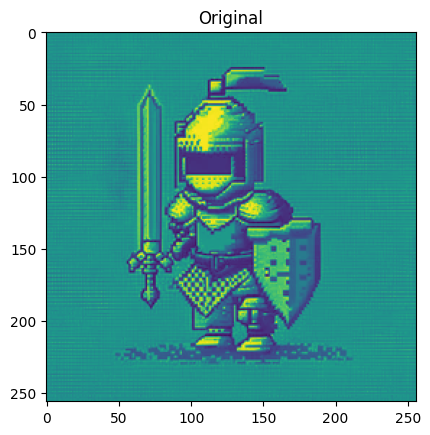

In [2]:
img = cv2.imread('imagen256.png', cv2.IMREAD_GRAYSCALE)
plt.title('Original')

plt.imshow(img)
plt.show()


Ruido gaussiano de la clase 10

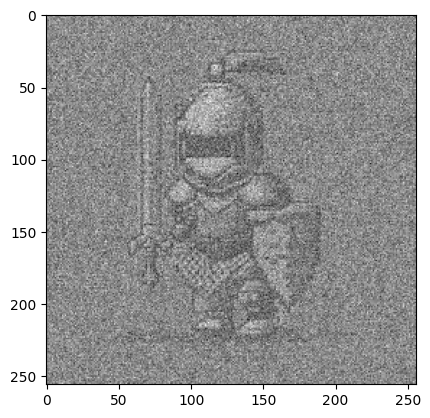

In [3]:
def agregar_ruido_gaussiano(img):
    imagen = cv2.normalize(img.astype(float),None,0.0,1.0,cv2.NORM_MINMAX)
    ruido = np.random.normal(loc=0.5, scale=0.3, size=img.shape)
    resultado = imagen + ruido
    return resultado

Ruido_gauss = agregar_ruido_gaussiano(img)


plt.figure()
plt.imshow(Ruido_gauss, cmap='gray')
plt.show()



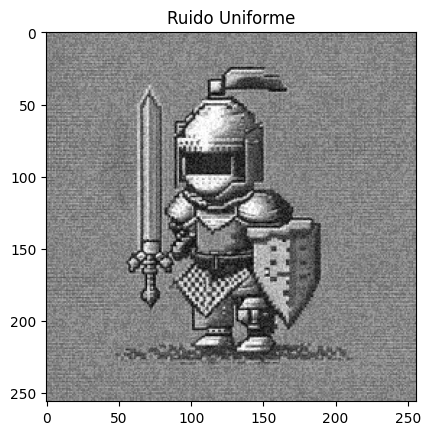

In [4]:
def agregar_ruido_uniforme(img, low=-0.1, high=0.1):
    """
    Agrega ruido uniforme a una imagen

    Parámetros:
    - img: imagen (puede estar en 0-1 o 0-255)
    - low: valor mínimo del ruido uniforme
    - high: valor máximo del ruido uniforme

    Retorna:
    - imagen con ruido uniforme aplicado
    """
    # Determinar si la imagen está normalizada
    is_normalized = img.max() <= 1.0
    
    # Si no está normalizada, normalizar primero
    if not is_normalized:
        img_float = img.astype(np.float64) / 255.0
        noise_scale = 1.0
    else:
        img_float = img.astype(np.float64)
        noise_scale = 1.0
        
    # Generar ruido uniforme en el rango [low, high]
    uniform_noise = np.random.uniform(low * noise_scale, high * noise_scale, img.shape)
    
    # Añadir ruido a la imagen
    noisy = img_float + uniform_noise
    
    # Clipear valores para mantenerlos en [0, 1]
    noisy_clipped = np.clip(noisy, 0, 1)
    
    # Devolver en el mismo formato que la entrada
    if not is_normalized:
        return (noisy_clipped * 255).astype(np.uint8)
    else:
        return noisy_clipped

uniforme = agregar_ruido_uniforme(img)

plt.imshow(uniforme, cmap='gray')
plt.title('Ruido Uniforme')
plt.show()



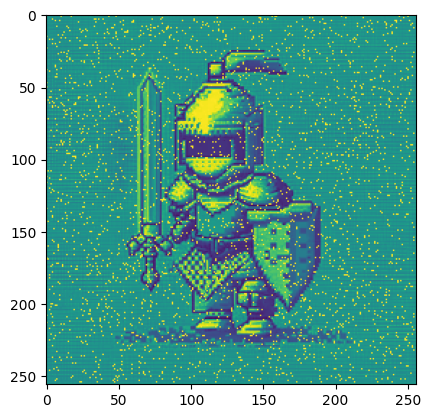

In [5]:
def agregar_ruido_sal(img, cantidad=0.05):
    """
    Agrega ruido impulsional tipo sal (píxeles blancos)

    Parámetros:
    - img: imagen (puede estar en 0-1 o 0-255)
    - cantidad: proporción de píxeles afectados
    """
    # Hacer una copia de la imagen
    noisy = np.copy(img)

    # Determinar si la imagen está normalizada o no
    is_normalized = img.max() <= 1.0
    max_val = 1.0 if is_normalized else 255.0

    # Generar máscara aleatoria
    num_salt = np.ceil(cantidad * img.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img.shape]

    # Aplicar ruido sal (píxeles blancos)
    noisy[coords[0], coords[1]] = max_val

    return noisy

sal = agregar_ruido_sal(img)

plt.imshow(sal)
plt.show()


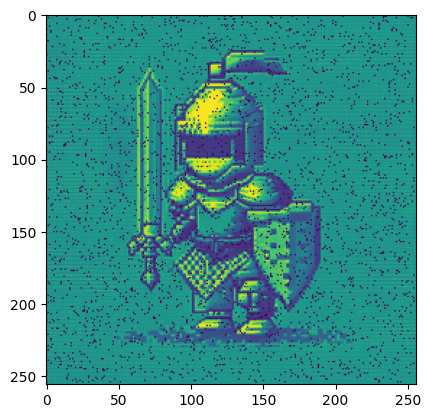

In [6]:
def agregar_ruido_pimienta(img, cantidad=0.05):



    ruido_p = np.copy(img)

    # Calcular número total de píxeles a afectar
    num_pepper = np.ceil(cantidad * img.size)

    # Generar coordenadas aleatorias para los píxeles a afectar
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img.shape]

    # Aplicar ruido pimienta (píxeles negros = 0)
    ruido_p[coords[0], coords[1]] = 0

    return ruido_p

pimienta = agregar_ruido_pimienta(img)

plt.imshow(pimienta)
plt.show()

# Análisis y Selección de Filtros para Cada Tipo de Ruido

## Descripción de los Tipos de Filtros Utilizados

### Filtros Lineales
Los filtros lineales aplican una operación de convolución a la imagen con un kernel predefinido. Estos filtros son efectivos para ruido con distribución estadística conocida, como el ruido gaussiano.

- **Filtro Gaussiano**: Utiliza un kernel con pesos distribuidos según una función gaussiana, dando mayor importancia a los píxeles centrales y menor a los periféricos.
- **Filtro de Media (Promedio)**: Reemplaza cada píxel por el promedio de sus vecinos, suavizando la imagen de manera uniforme.

### Filtros de Orden Estadístico
Estos filtros operan reordenando los valores de los píxeles en una ventana y seleccionando un valor específico según su posición en el orden.

- **Filtro de Mediana**: Ordena los valores de los píxeles vecinos y selecciona el valor central, eliminando efectivamente valores atípicos.
- **Filtro de Mínimo**: Selecciona el valor mínimo en la ventana, útil para eliminar ruido "sal".
- **Filtro de Máximo**: Selecciona el valor máximo, efectivo para eliminar ruido "pimienta".

### Filtros Adaptativos
Los filtros adaptativos ajustan sus parámetros según las características locales de la imagen, ofreciendo un mejor equilibrio entre reducción de ruido y preservación de detalles.

- **Filtro Wiener Local**: Aplica un filtrado óptimo basado en la estimación local de la media y varianza, adaptándose a las características de cada región.
- **Filtro Adaptativo de Media**: Ajusta la cantidad de suavizado según la varianza local de la región.

## Resultados y Justificación de la Selección

Para cada tipo de ruido, se seleccionó el filtro más adecuado basado en sus características específicas y la naturaleza del ruido:

1. **Ruido Gaussiano → Filtro Gaussiano (Lineal)**
2. **Ruido Uniforme → Filtro Wiener Local (Adaptativo)**
3. **Ruido Sal → Filtro Mínimo (Orden Estadístico)**
4. **Ruido Pimienta → Filtro Mediana (Orden Estadístico)**

Esta combinación de filtros permite abordar diferentes tipos de ruido utilizando las tres familias principales de filtros espaciales, optimizando tanto la reducción de ruido como la preservación de detalles importantes en la imagen.

#### Parte 2
Restaure la imagen del siguiente código empleando el filtro de Wiener y el filtro Paramétrico.
Determine el parámetro que mejor resultado genere (no modifique el código):

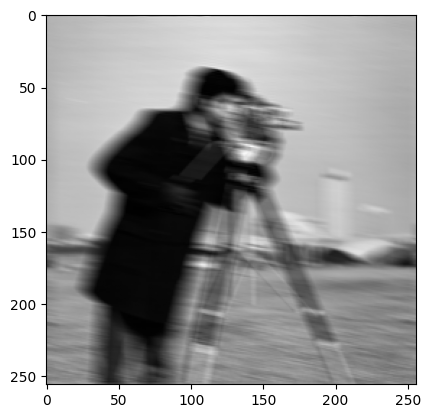

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
gray = cv2.normalize(img.astype('float'), None, 0.0, 1.0, cv2.NORM_MINMAX)
F = np.fft.fft2(gray)
vector = np.linspace(-0.5, 0.5, gray.shape[0])
U,V = np.meshgrid(vector, vector)
a = 5
b = 1
UV = U*a+V*b
G = F*np.fft.fftshift(np.sinc(np.pi*UV)*np.exp(-1j*np.pi*UV))
g = np.real(np.fft.ifft2(G))
plt.figure()
plt.imshow(g, cmap='gray')
plt.show()

# Restauración de Imágenes Degradadas mediante Filtros en el Dominio de la Frecuencia

En esta sección, trabajamos con una imagen que ha sido degradada por un proceso de movimiento lineal, modelado mediante la función sinc en el dominio de la frecuencia. Este tipo de degradación simula el desenfoque por movimiento que ocurre cuando se captura una imagen con un tiempo de exposición largo mientras la cámara o el objeto se mueven.

## Proceso de Degradación

La imagen original `gray` se convirtió al dominio de la frecuencia mediante la Transformada de Fourier (FFT). Luego se aplicó una función de degradación `H` donde:
- a = 5 y b = 1 son los parámetros que definen la dirección y magnitud del movimiento
- La función sinc provoca el característico efecto de desenfoque direccional
- El término exponencial agrega el desplazamiento de fase correspondiente

## Filtros de Restauración Implementados

Para recuperar la imagen original a partir de la degradada, se implementaron dos técnicas de restauración:

1. **Filtro de Wiener**: Opera minimizando el error cuadrático medio entre la imagen original y la restaurada, incorporando información sobre la relación señal-ruido mediante el parámetro K.
2. **Filtro Paramétrico (Regularizado)**: Estabiliza la inversión del filtro mediante un parámetro de regularización γ que evita la amplificación excesiva del ruido.
Los parámetros de cada filtro (K y γ) deben ajustarse cuidadosamente para encontrar un equilibrio óptimo entre la recuperación de detalles y la supresión del ruido.

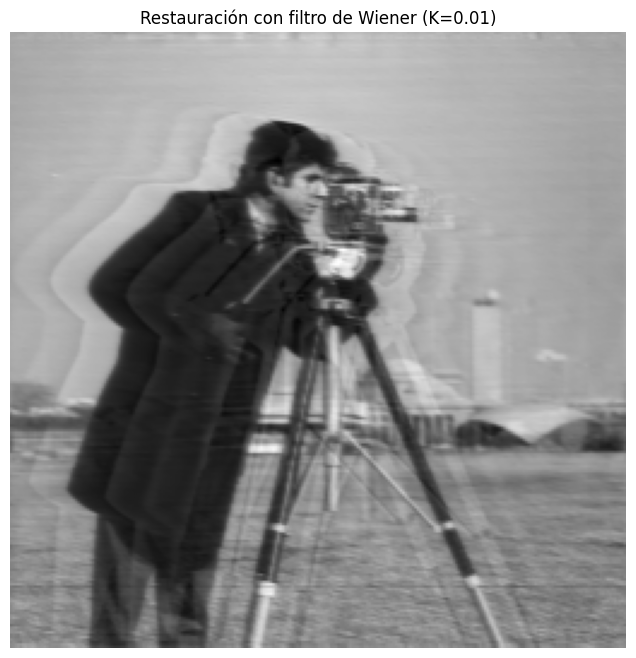

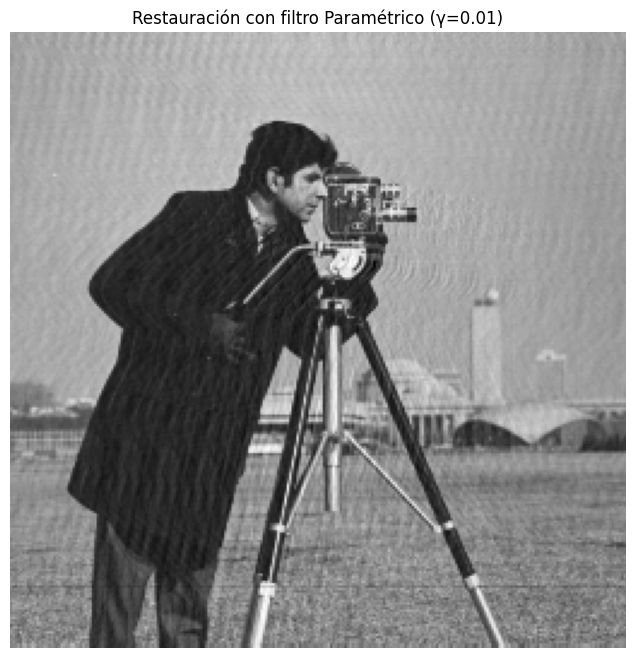

In [14]:
# Definir correctamente la función de degradación en el dominio de la frecuencia
H = np.fft.fftshift(np.sinc(np.pi*UV)*np.exp(-1j*np.pi*UV))

# === Filtro de Wiener (K=0.01) ===
def filtro_wiener(G, H, K=0.01):
    """
    Restaura una imagen usando el filtro de Wiener
    
    Parámetros:
    - G: Imagen degradada en el dominio de la frecuencia
    - H: Función de transferencia de la degradación
    - K: Parámetro de relación señal-ruido
    """
    H_conj = np.conj(H)
    H_abs2 = np.abs(H)**2
    F_hat = (H_conj / (H_abs2 + K)) * G
    return np.real(np.fft.ifft2(F_hat))

# Experimentar con diferentes valores de K
K_value = 0.01
restaurada_wiener = filtro_wiener(G, H, K=K_value)
plt.figure(figsize=(8, 8))
plt.imshow(restaurada_wiener, cmap='gray')
plt.title(f"Restauración con filtro de Wiener (K={K_value})")
plt.axis('off')
plt.show()

# === Filtro Paramétrico (γ=0.01) ===
def filtro_parametrico(G, H, gamma=0.001):
    """
    Restaura una imagen usando el filtro paramétrico
    
    Parámetros:
    - G: Imagen degradada en el dominio de la frecuencia
    - H: Función de transferencia de la degradación
    - gamma: Parámetro de regularización
    """
    F_hat = G / (H + gamma)
    return np.real(np.fft.ifft2(F_hat))

# Experimentar con diferentes valores de gamma
gamma_value = 0.01
restaurada_param = filtro_parametrico(G, H, gamma=gamma_value)
plt.figure(figsize=(8, 8))
plt.imshow(restaurada_param, cmap='gray')
plt.title(f"Restauración con filtro Paramétrico (γ={gamma_value})")
plt.axis('off')
plt.show()

# Referencias
Anotar referencias en formato APA.